# Huấn luyện KNN (K láng giềng gần nhất)

**KNN** dự đoán dựa trên k ca bệnh giống nhất trong dữ liệu.

> Nhớ chạy `02_tien_xu_ly/tien_xu_ly_data.ipynb` trước để có `features.csv`.

## KNN hoạt động thế nào? (công thức)

Với một ca bệnh mới là vector triệu chứng $x$, KNN làm 3 bước:

**1. Tính khoảng cách** từ $x$ tới mọi ca trong tập huấn luyện (mặc định: khoảng cách Euclid)

$$d(x, x_i)=\sqrt{\sum_{j=1}^{135}\left(x_j-x_{ij}\right)^2}$$

**2. Chọn $k$ ca gần nhất.**

**3. Bỏ phiếu đa số:** bệnh xuất hiện nhiều nhất trong $k$ ca đó là kết quả.

**Tham số chính – `n_neighbors` ($k$):**
- $k$ nhỏ ($k=1$): bám sát dữ liệu, rất nhạy nhiễu → dễ **quá khớp**.
- $k$ lớn: dự đoán mượt hơn nhưng dễ bỏ qua bệnh hiếm → **chưa khớp**.

> KNN là *lazy learner*: huấn luyện gần như tức thì (chỉ lưu dữ liệu), nhưng **chậm khi dự đoán** vì phải so với toàn bộ tập train.

## Bước 1. Đọc dữ liệu đã tiền xử lý

In [1]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Đọc dữ liệu đã tiền xử lý (chạy notebook tien_xu_ly_data.ipynb trước)
data = pd.read_csv("../01_data/processed/features.csv")

X = data.drop(columns=["Benh"])     # các cột triệu chứng
y = data["Benh"]                    # nhãn bệnh (dạng chữ)

le = LabelEncoder()
y_num = le.fit_transform(y)         # đổi nhãn chữ -> số

X_train, X_test, y_train, y_test = train_test_split( #5000 dòng dữ liệu, 4000 dòng train, 1000 dòng test
    X, y_num, test_size=0.2, random_state=42, stratify=y_num)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Số bệnh:", len(le.classes_))


Train: (4000, 135) | Test: (1000, 135) | Số bệnh: 400


## Bước 2. Huấn luyện và đánh giá

In [2]:
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5) #gọi model huấn luyện thuật toán KNN
model.fit(X_train, y_train) #huấn luyện 

y_pred = model.predict(X_test) #test
print("Độ chính xác trên tập test:", round(accuracy_score(y_test, y_pred), 3))


Độ chính xác trên tập test: 0.278


## Bước 3. Đường cong học tập theo tham số

Thử nhiều giá trị của **`n_neighbors`** để xem mô hình tốt nhất ở đâu.
- Đường **Train** cao mà **Kiểm tra (CV)** thấp ⇒ **quá khớp** (overfitting).
- Cả hai cùng thấp ⇒ **chưa khớp** (underfitting).


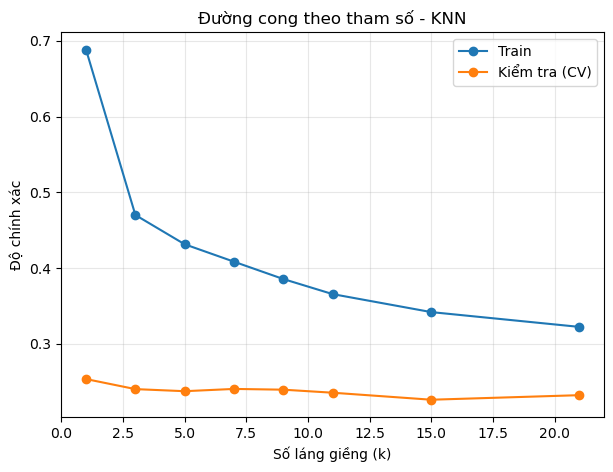

Giá trị n_neighbors tốt nhất: 1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve

gia_tri = [1, 3, 5, 7, 9, 11, 15, 21]  ###data train 4000 dòng; cv 3: train 1, train 2, train 3
#train 1 train2 để train, 3 để test
#1 và 3 train, 2 test
#2 và 3train, 1 test

#1 và 2 train, 1 và 2 
train_sc, val_sc = validation_curve(
    KNeighborsClassifier(), X_train, y_train,
    param_name="n_neighbors", param_range=gia_tri,
    cv=3, scoring="accuracy")

plt.figure(figsize=(7,5))
plt.plot(gia_tri, train_sc.mean(axis=1), "o-", label="Train")
plt.plot(gia_tri, val_sc.mean(axis=1), "o-", label="Kiểm tra (CV)")

plt.xlabel("Số láng giềng (k)"); plt.ylabel("Độ chính xác")
plt.title("Đường cong theo tham số - KNN")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

tot_nhat = gia_tri[int(np.argmax(val_sc.mean(axis=1)))]
print("Giá trị n_neighbors tốt nhất:", tot_nhat)


## Bước 4. Đường cong học tập theo số lượng mẫu

Xem mô hình có học tốt hơn khi có **nhiều dữ liệu** hơn không.

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


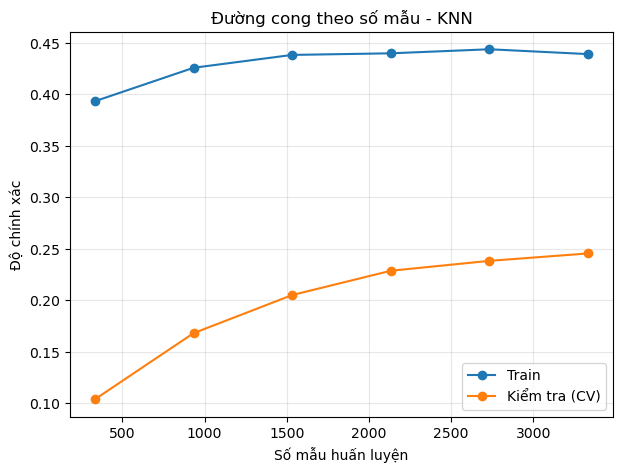

In [5]:
from sklearn.model_selection import learning_curve

sizes, train_sc2, val_sc2 = learning_curve(
    model, X, y_num, cv=3, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6))

plt.figure(figsize=(7,5))
plt.plot(sizes, train_sc2.mean(axis=1), "o-", label="Train")
plt.plot(sizes, val_sc2.mean(axis=1), "o-", label="Kiểm tra (CV)")
plt.xlabel("Số mẫu huấn luyện"); plt.ylabel("Độ chính xác")
plt.title("Đường cong theo số mẫu - KNN")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


## Bước 5. Lưu mô hình

In [6]:
import pickle
with open("knn_model.pkl", "wb") as f:
    pickle.dump({"model": model, "label_encoder": le}, f)
print("Đã lưu knn_model.pkl")


Đã lưu knn_model.pkl
